#  Viscous Burgers' Equation and Cole–Hopf Analytical Solution

## Governing Equation

We consider the 1D viscous Burgers' equation:

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x}
= \nu \frac{\partial^2 u}{\partial x^2}
$$

---

## Conservative Form

The equation can also be written in conservative form:

$$
\frac{\partial u}{\partial t}

* \frac{\partial}{\partial x}\left(\frac{u^2}{2}\right)
  = \nu \frac{\partial^2 u}{\partial x^2}
  $$

---

## Cole–Hopf Transformation

Introduce a transformation:

$$
u(x,t) = -2\nu \frac{\partial}{\partial x} \ln \phi(x,t) + 4
$$

which implies:

$$
u = -2\nu \frac{\phi_x}{\phi} + 4
$$

---

## Transformed Equation

Under this transformation, the nonlinear Burgers' equation reduces to the linear heat equation:

$$
\frac{\partial \phi}{\partial t}
= \nu \frac{\partial^2 \phi}{\partial x^2}
$$

---

## Analytical Solution for (\phi)

For periodic boundary conditions, the solution is constructed as:

$$
\phi(x,t) =
\exp\left(-\frac{(x - 4t)^2}{4\nu(t+1)}\right)
+
\exp\left(-\frac{(x - 4t - 2\pi)^2}{4\nu(t+1)}\right)
$$

---

## Final Analytical Solution for (u(x,t))

$$
u(x,t) = -2\nu \frac{\phi_x}{\phi} + 4
$$

---

## Initial Condition

At (t = 0), the analytical solution is used to initialize the numerical scheme:

$$
u(x,0) = -2\nu \frac{\phi_x(x,0)}{\phi(x,0)} + 4
$$
---

## Diagnostics

### Mass (Conserved Quantity)

$$
M(t) = \int u(x,t),dx
$$

Discrete form:

$$
M \approx \sum_i u_i , \Delta x
$$

---

### L1 Error

$$
L_1 = \int |u_{\text{num}} - u_{\text{exact}}| , dx
$$

Discrete form:

$$
L_1 \approx \sum_i |u_i - u_i^{\text{exact}}| , \Delta x
$$

---

### Relative L1 Error

$$
L_1^{rel} =
\frac{\sum_i |u_i - u_i^{\text{exact}}|}
{\sum_i |u_i^{\text{exact}}|}
$$

---

## Numerical Scheme Used

* Non-conservative convection: (u u_x)
* Central diffusion: (u_{xx})
* Lax–Friedrichs artificial viscosity

---

## Key Notes

* The analytical solution is **smooth due to viscosity**
* Non-conservative schemes may:

  * violate conservation
  * introduce artificial diffusion
* L1 error quantifies **accuracy**
* Mass error quantifies **physical consistency**


#  Numerical Schemes for 1D Burgers' Equation (Conservative vs Non-Conservative)

---

## Governing Equation

### Conservative Form

$$
\frac{\partial u}{\partial t}

* \frac{\partial}{\partial x}\left(\frac{u^2}{2}\right)
  = \nu \frac{\partial^2 u}{\partial x^2}
  $$

### Non-Conservative Form

$$
\frac{\partial u}{\partial t}

* u \frac{\partial u}{\partial x}
  = \nu \frac{\partial^2 u}{\partial x^2}
  $$

---

# 🔹 Non-Conservative Scheme (with Lax–Friedrichs viscosity)

We discretize:

$$
u \frac{\partial u}{\partial x}
\approx u_i \frac{u_i - u_{i-1}}{\Delta x}
$$

$$
\frac{\partial^2 u}{\partial x^2}
\approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}
$$

---

## Final Discrete Update

$$
u_i^{n+1} =
u_i^n

* u_i^n \frac{\Delta t}{\Delta x}(u_i^n - u_{i-1}^n)

- \nu \frac{\Delta t}{\Delta x^2}(u_{i+1}^n - 2u_i^n + u_{i-1}^n)
- \frac{\alpha \Delta t}{2\Delta x}(u_{i+1}^n - 2u_i^n + u_{i-1}^n)
  $$

---

## Interpretation

* First term → convection (upwind-like)
* Second term → physical diffusion
* Third term → **Lax–Friedrichs artificial viscosity**

$$
\alpha = \max |u|
$$

---

## Effective Viscosity

$$
\nu_{\text{eff}} =
\nu + \frac{\alpha \Delta x}{2}
$$

---

# 🔹 Conservative Scheme (Rusanov / Local Lax–Friedrichs)

We define flux:

$$
f(u) = \frac{u^2}{2}
$$

---

## Numerical Flux at Interface

$$
F_{i+\frac{1}{2}} =
\frac{1}{2}(f_i + f_{i+1})

* \frac{1}{2} \alpha (u_{i+1} - u_i)
  $$

---

## Finite Volume Update

$$
u_i^{n+1} =
u_i^n

* \frac{\Delta t}{\Delta x}
  \left(F_{i+\frac{1}{2}} - F_{i-\frac{1}{2}}\right)

- \nu \frac{\Delta t}{\Delta x^2}
  (u_{i+1}^n - 2u_i^n + u_{i-1}^n)
  $$




# 1D viscous Burgers equation in non-conservative form

dt = 0.00180

--- Diagnostics ---
Initial mass      : 2.538407e+01
Final mass        : 2.513402e+01
L1 error          : 6.252659e-01
Relative L1 error : 2.465316e-02


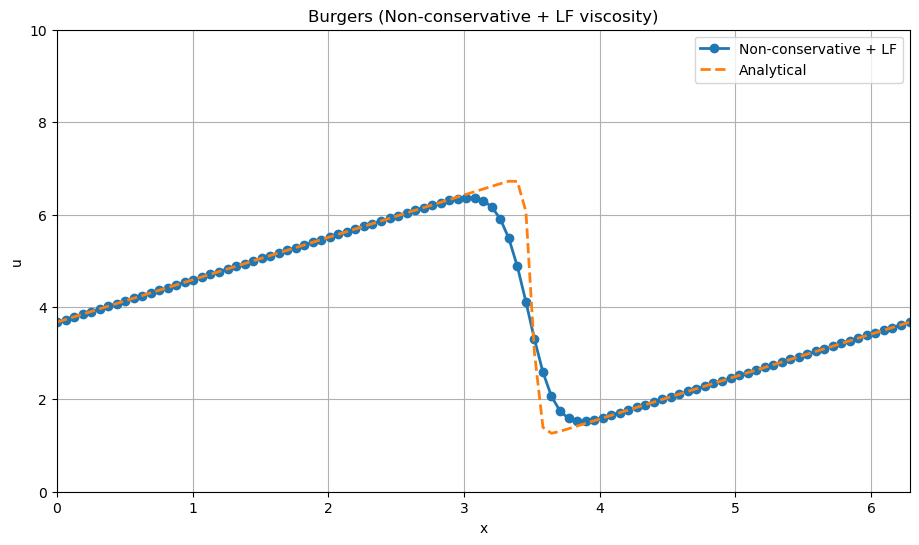

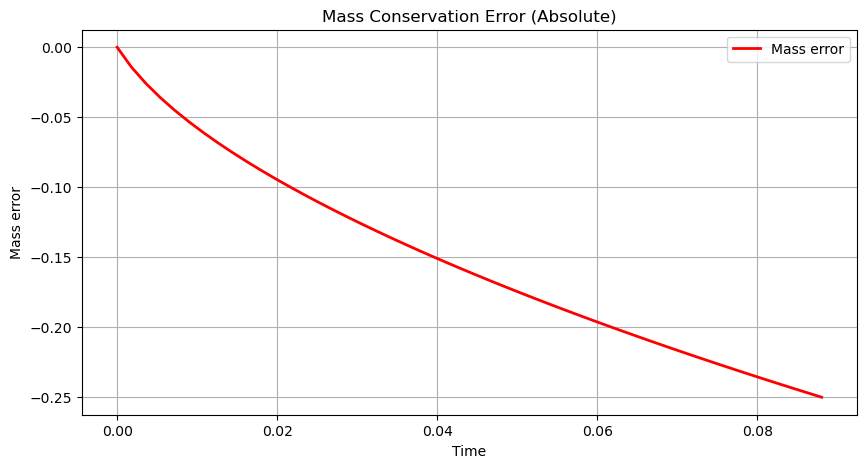

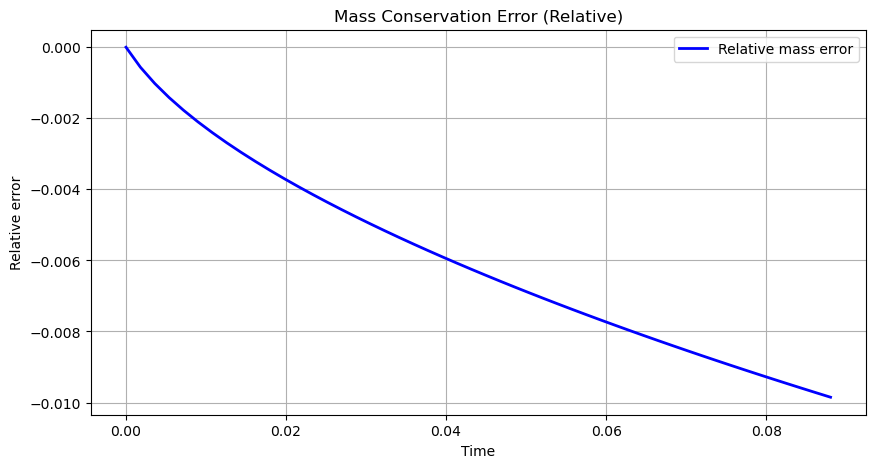

In [1]:
# %%
import numpy as np
import sympy as sp
from sympy.utilities.lambdify import lambdify
import matplotlib.pyplot as plt

# %%
# --- Analytical solution (Cole–Hopf) ---
x_sym, nu_sym, t_sym = sp.symbols('x nu t')

phi = (sp.exp(-(x_sym - 4 * t_sym)**2 / (4 * nu_sym * (t_sym + 1))) +
       sp.exp(-(x_sym - 4 * t_sym - 2 * sp.pi)**2 / (4 * nu_sym * (t_sym + 1))))

phiprime = phi.diff(x_sym)
u_expr = -2 * nu_sym * (phiprime / phi) + 4

ufunc = lambdify((t_sym, x_sym, nu_sym), u_expr)

# %%
# --- Grid ---
nx = 101
nt = 50
L = 2 * np.pi

dx = L / (nx - 1)
nu_val = 0.07

x = np.linspace(0, L, nx)

# %%
# --- Initial condition ---
t0 = 0.0
u = np.array([ufunc(t0, xi, nu_val) for xi in x])

# %%
# --- CFL-safe time step ---
dt = min(0.2 * dx / np.max(np.abs(u)),
         0.2 * dx**2 / nu_val)

print(f"dt = {dt:.5f}")

# %%
# --- Mass computation function ---
def compute_mass(u, dx):
    return np.sum(u) * dx

# %%
# --- Time marching (Non-conservative + LF viscosity) ---
mass_history = []
time_history = []

for n in range(nt):
    un = u.copy()

    # store mass BEFORE update (optional: after also works)
    mass_history.append(compute_mass(un, dx))
    time_history.append(n * dt)

    # LF wave speed
    alpha = np.max(np.abs(un))

    # Interior update
    u[1:-1] = un[1:-1] \
        - un[1:-1] * dt/dx * (un[1:-1] - un[:-2]) \
        + nu_val * dt/dx**2 * (un[2:] - 2*un[1:-1] + un[:-2]) \
        + (alpha * dt / (2*dx)) * (un[2:] - 2*un[1:-1] + un[:-2])

    # Periodic BC (left boundary)
    u[0] = un[0] \
        - un[0] * dt/dx * (un[0] - un[-2]) \
        + nu_val * dt/dx**2 * (un[1] - 2*un[0] + un[-2]) \
        + (alpha * dt / (2*dx)) * (un[1] - 2*un[0] + un[-2])

    u[-1] = u[0]

# %%
# --- Analytical solution ---
t_final = nt * dt
u_analytical = np.array([ufunc(t_final, xi, nu_val) for xi in x])

# %%
# --- Mass error ---
mass_history = np.array(mass_history)
mass_initial = mass_history[0]

mass_error = mass_history - mass_initial
rel_mass_error = mass_error / mass_initial
L1 = np.sum(np.abs(u - u_analytical)) * dx
# %%
# --- L1 Error ---
L1_error = np.sum(np.abs(u - u_analytical)) * dx
L1_rel_error = L1_error / (np.sum(np.abs(u_analytical)) * dx)



print("\n--- Diagnostics ---")
print(f"Initial mass      : {mass_initial:.6e}")
print(f"Final mass        : {mass_history[-1]:.6e}")
print(f"L1 error          : {L1_error:.6e}")
print(f"Relative L1 error : {L1_rel_error:.6e}")
# %%
# --- Plot solution ---
plt.figure(figsize=(11, 6))
plt.plot(x, u, 'o-', lw=2, label='Non-conservative + LF')
plt.plot(x, u_analytical, '--', lw=2, label='Analytical')
plt.xlim([0, L])
plt.ylim([0, 10])
plt.xlabel('x')
plt.ylabel('u')
plt.title('Burgers (Non-conservative + LF viscosity)')
plt.legend()
plt.grid()
plt.show()

# %%
# --- Plot mass conservation ---
plt.figure(figsize=(10, 5))
plt.plot(time_history, mass_error, 'r-', lw=2, label='Mass error')
plt.xlabel('Time')
plt.ylabel('Mass error')
plt.title('Mass Conservation Error (Absolute)')
plt.grid()
plt.legend()
plt.show()

# %%
# --- Plot relative error ---
plt.figure(figsize=(10, 5))
plt.plot(time_history, rel_mass_error, 'b-', lw=2, label='Relative mass error')
plt.xlabel('Time')
plt.ylabel('Relative error')
plt.title('Mass Conservation Error (Relative)')
plt.grid()
plt.legend()
plt.show()

# 1D viscous Burgers equation in conservative form

dt = 0.00180

--- Diagnostics ---
Initial mass      : 2.513274e+01
Final mass        : 2.513274e+01
L1 error          : 4.385473e-01
Relative L1 error : 1.744982e-02


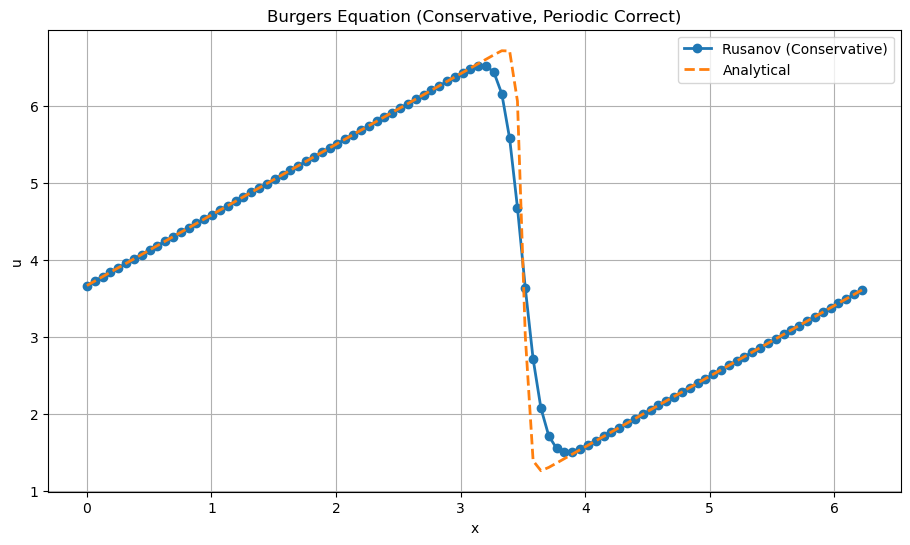

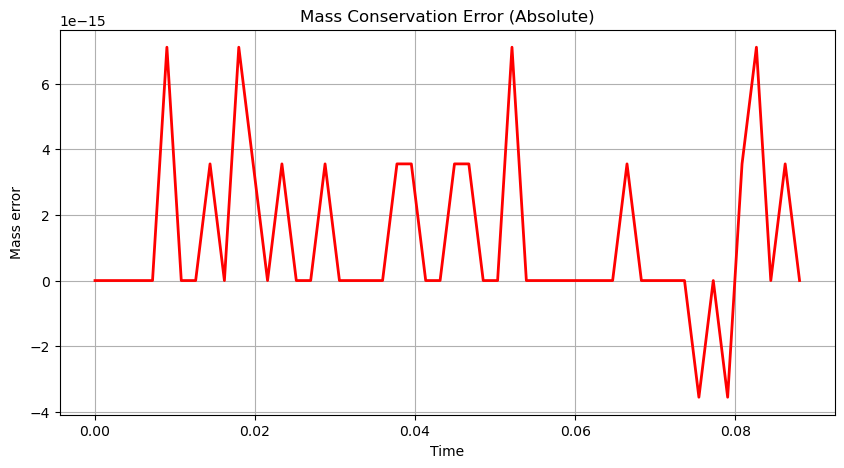

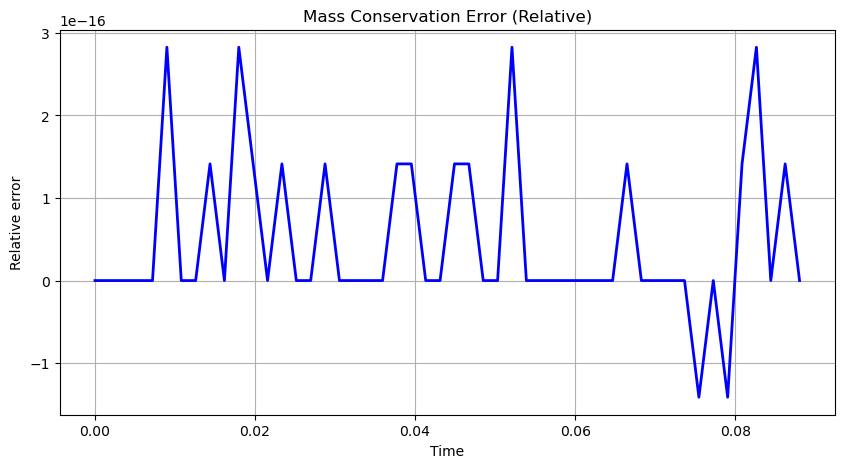

In [2]:
# %%
import numpy as np
import sympy as sp
from sympy.utilities.lambdify import lambdify
import matplotlib.pyplot as plt

# %%
# --- Symbolic analytical solution (Cole–Hopf) ---
x_sym, nu_sym, t_sym = sp.symbols('x nu t')

phi = (sp.exp(-(x_sym - 4 * t_sym)**2 / (4 * nu_sym * (t_sym + 1))) +
       sp.exp(-(x_sym - 4 * t_sym - 2 * sp.pi)**2 / (4 * nu_sym * (t_sym + 1))))

phiprime = phi.diff(x_sym)
u_expr = -2 * nu_sym * (phiprime / phi) + 4

ufunc = lambdify((t_sym, x_sym, nu_sym), u_expr)

# %%
# --- Grid setup (FIXED: no duplicate periodic point) ---
nx = 100              # NOTE: use 100 (not 101)
nt = 50
L = 2 * np.pi

dx = L / nx
nu_val = 0.07

x = np.linspace(0, L, nx, endpoint=False)

# %%
# --- Initial condition ---
t0 = 0.0
u = np.array([ufunc(t0, xi, nu_val) for xi in x])

# %%
# --- Time step ---
dt = min(0.2 * dx / np.max(np.abs(u)),
         0.2 * dx**2 / nu_val)

print(f"dt = {dt:.5f}")

# %%
# --- Mass function ---
def compute_mass(u, dx):
    return np.sum(u) * dx

# %%
# --- Time marching (Conservative Rusanov + diffusion, periodic via roll) ---
mass_history = []
time_history = []

for n in range(nt):
    un = u.copy()

    # Track mass
    mass_history.append(compute_mass(un, dx))
    time_history.append(n * dt)

    # Conservative flux f = u^2 / 2
    f = 0.5 * un**2

    # Rusanov flux (periodic via np.roll)
    alpha = np.max(np.abs(un))

    flux_right = 0.5 * (f + np.roll(f, -1)) \
                 - 0.5 * alpha * (np.roll(un, -1) - un)

    flux_left = np.roll(flux_right, 1)

    # Update
    u = un \
        - dt/dx * (flux_right - flux_left) \
        + nu_val * dt/dx**2 * (np.roll(un, -1) - 2*un + np.roll(un, 1))

# %%
# --- Analytical solution ---
t_final = nt * dt
u_analytical = np.array([ufunc(t_final, xi, nu_val) for xi in x])

# %%
# --- Mass error ---
mass_history = np.array(mass_history)
mass_initial = mass_history[0]

mass_error = mass_history - mass_initial
rel_mass_error = mass_error / mass_initial

L1 = np.sum(np.abs(u - u_analytical)) * dx
# %%
# --- L1 Error ---
L1_error = np.sum(np.abs(u - u_analytical)) * dx
L1_rel_error = L1_error / (np.sum(np.abs(u_analytical)) * dx)



print("\n--- Diagnostics ---")
print(f"Initial mass      : {mass_initial:.6e}")
print(f"Final mass        : {mass_history[-1]:.6e}")
print(f"L1 error          : {L1_error:.6e}")
print(f"Relative L1 error : {L1_rel_error:.6e}")
# %%

# %%
# --- Plot solution ---
plt.figure(figsize=(11, 6))
plt.plot(x, u, 'o-', lw=2, label='Rusanov (Conservative)')
plt.plot(x, u_analytical, '--', lw=2, label='Analytical')
plt.xlabel('x')
plt.ylabel('u')
plt.title('Burgers Equation (Conservative, Periodic Correct)')
plt.legend()
plt.grid()
plt.show()

# %%
# --- Plot absolute mass error ---
plt.figure(figsize=(10, 5))
plt.plot(time_history, mass_error, 'r-', lw=2)
plt.xlabel('Time')
plt.ylabel('Mass error')
plt.title('Mass Conservation Error (Absolute)')
plt.grid()
plt.show()

# %%
# --- Plot relative mass error ---
plt.figure(figsize=(10, 5))
plt.plot(time_history, rel_mass_error, 'b-', lw=2)
plt.xlabel('Time')
plt.ylabel('Relative error')
plt.title('Mass Conservation Error (Relative)')
plt.grid()
plt.show()

# 2D viscous Burgers equation in conservative form

dt = 0.00491
Initial mass: 78.956835208715
Final mass:   78.956835208715


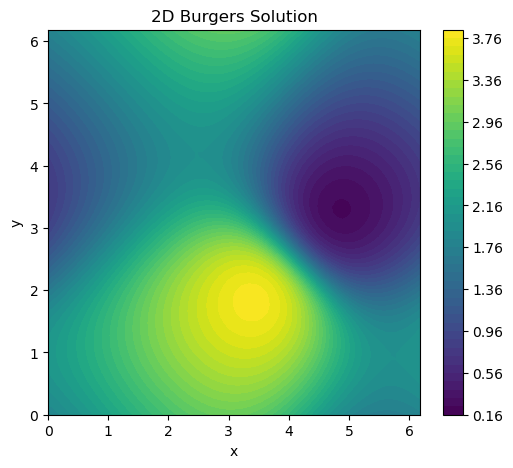

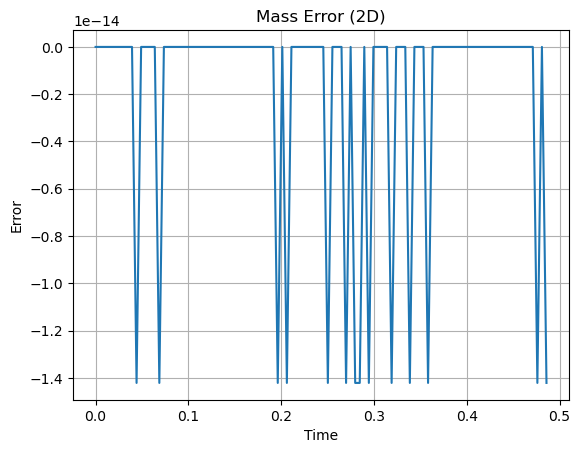

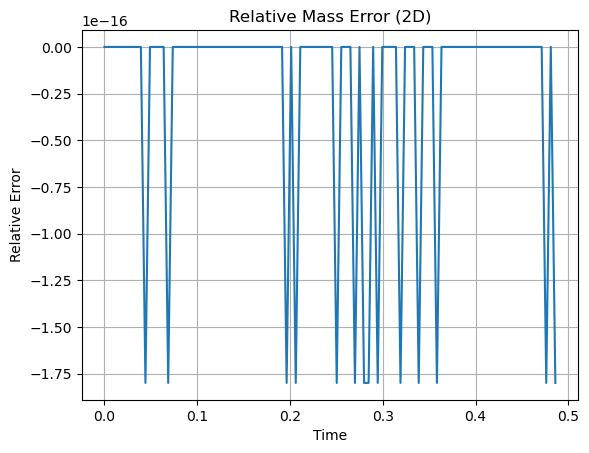

In [3]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# %%
# --- Grid ---
nx, ny = 64, 64
Lx, Ly = 2*np.pi, 2*np.pi

dx = Lx / nx
dy = Ly / ny

x = np.linspace(0, Lx, nx, endpoint=False)
y = np.linspace(0, Ly, ny, endpoint=False)

X, Y = np.meshgrid(x, y, indexing='ij')

# %%
# --- Parameters ---
nu = 0.05
nt = 100

# %%
# --- Initial condition (smooth periodic bump) ---
u = 2 + np.sin(X) + np.cos(Y)

# %%
# --- Time step (CFL) ---
dt = min(0.2 * dx / np.max(np.abs(u)),
         0.2 * dx**2 / nu)

print(f"dt = {dt:.5f}")

# %%
# --- Mass function ---
def compute_mass(u):
    return np.sum(u) * dx * dy

# %%
# --- Time marching ---
mass_history = []
time_history = []

for n in range(nt):
    un = u.copy()

    mass_history.append(compute_mass(un))
    time_history.append(n * dt)

    # Flux
    f = 0.5 * un**2

    alpha = np.max(np.abs(un))

    # --- X-direction flux ---
    flux_x_r = 0.5 * (f + np.roll(f, -1, axis=0)) \
               - 0.5 * alpha * (np.roll(un, -1, axis=0) - un)

    flux_x_l = np.roll(flux_x_r, 1, axis=0)

    # --- Y-direction flux ---
    flux_y_r = 0.5 * (f + np.roll(f, -1, axis=1)) \
               - 0.5 * alpha * (np.roll(un, -1, axis=1) - un)

    flux_y_l = np.roll(flux_y_r, 1, axis=1)

    # --- Update ---
    u = un \
        - dt/dx * (flux_x_r - flux_x_l) \
        - dt/dy * (flux_y_r - flux_y_l) \
        + nu * dt * (
            (np.roll(un, -1, axis=0) - 2*un + np.roll(un, 1, axis=0)) / dx**2 +
            (np.roll(un, -1, axis=1) - 2*un + np.roll(un, 1, axis=1)) / dy**2
        )

# %%
# --- Mass error ---
mass_history = np.array(mass_history)
mass_initial = mass_history[0]

mass_error = mass_history - mass_initial
rel_mass_error = mass_error / mass_initial

print(f"Initial mass: {mass_initial:.12f}")
print(f"Final mass:   {mass_history[-1]:.12f}")

# %%
# --- Plot solution ---
plt.figure(figsize=(6,5))
plt.contourf(X, Y, u, 50)
plt.colorbar()
plt.title("2D Burgers Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# %%
# --- Plot mass error ---
plt.figure()
plt.plot(time_history, mass_error)
plt.title("Mass Error (2D)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid()
plt.show()

# %%
# --- Relative error ---
plt.figure()
plt.plot(time_history, rel_mass_error)
plt.title("Relative Mass Error (2D)")
plt.xlabel("Time")
plt.ylabel("Relative Error")
plt.grid()
plt.show()

# 2D viscous Burgers equation in non-conservative form

dt = 0.00491
Initial mass: 78.956835208715
Final mass:   78.090200724158


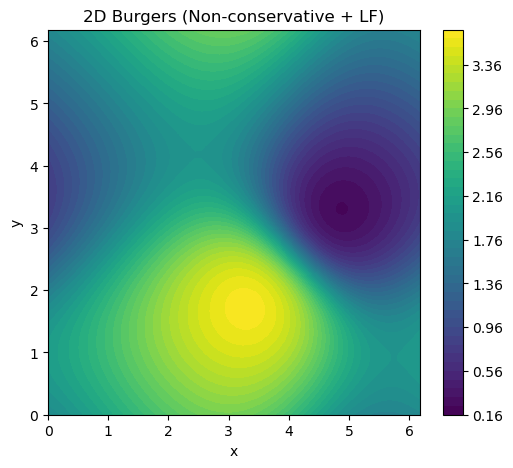

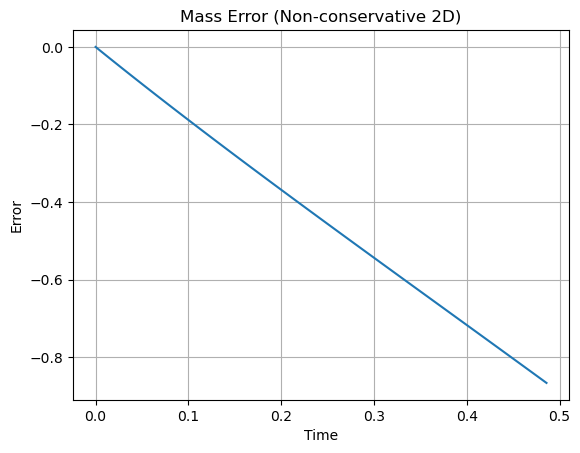

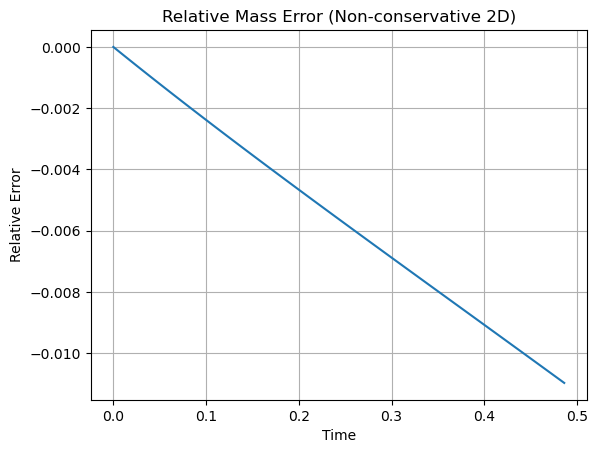

In [4]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# %%
# --- Grid ---
nx, ny = 64, 64
Lx, Ly = 2*np.pi, 2*np.pi

dx = Lx / nx
dy = Ly / ny

x = np.linspace(0, Lx, nx, endpoint=False)
y = np.linspace(0, Ly, ny, endpoint=False)

X, Y = np.meshgrid(x, y, indexing='ij')

# %%
# --- Parameters ---
nu = 0.05
nt = 100

# %%
# --- Initial condition ---
u = 2 + np.sin(X) + np.cos(Y)

# %%
# --- Time step ---
dt = min(0.2 * dx / np.max(np.abs(u)),
         0.2 * dx**2 / nu)

print(f"dt = {dt:.5f}")

# %%
# --- Mass function ---
def compute_mass(u):
    return np.sum(u) * dx * dy

# %%
# --- Time marching (Non-conservative + LF viscosity) ---
mass_history = []
time_history = []

for n in range(nt):
    un = u.copy()

    mass_history.append(compute_mass(un))
    time_history.append(n * dt)

    alpha = np.max(np.abs(un))

    # --- derivatives (backward differencing like your 1D code) ---
    ux = (un - np.roll(un, 1, axis=0)) / dx
    uy = (un - np.roll(un, 1, axis=1)) / dy

    # --- diffusion ---
    lap = (
        (np.roll(un, -1, axis=0) - 2*un + np.roll(un, 1, axis=0)) / dx**2 +
        (np.roll(un, -1, axis=1) - 2*un + np.roll(un, 1, axis=1)) / dy**2
    )

    # --- LF artificial viscosity (same structure as 1D) ---
    lf_visc = (
        (np.roll(un, -1, axis=0) - 2*un + np.roll(un, 1, axis=0)) / dx +
        (np.roll(un, -1, axis=1) - 2*un + np.roll(un, 1, axis=1)) / dy
    )

    # --- update ---
    u = un \
        - dt * (un * ux + un * uy) \
        + nu * dt * lap \
        + (alpha * dt / 2.0) * lf_visc

# %%
# --- Mass error ---
mass_history = np.array(mass_history)
mass_initial = mass_history[0]

mass_error = mass_history - mass_initial
rel_mass_error = mass_error / mass_initial

print(f"Initial mass: {mass_initial:.12f}")
print(f"Final mass:   {mass_history[-1]:.12f}")

# %%
# --- Plot solution ---
plt.figure(figsize=(6,5))
plt.contourf(X, Y, u, 50)
plt.colorbar()
plt.title("2D Burgers (Non-conservative + LF)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# %%
# --- Plot mass error ---
plt.figure()
plt.plot(time_history, mass_error)
plt.title("Mass Error (Non-conservative 2D)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid()
plt.show()

# %%
# --- Relative error ---
plt.figure()
plt.plot(time_history, rel_mass_error)
plt.title("Relative Mass Error (Non-conservative 2D)")
plt.xlabel("Time")
plt.ylabel("Relative Error")
plt.grid()
plt.show()


#  Key Differences

| Feature           | Non-Conservative | Conservative         |
| ----------------- | ---------------- | -------------------- |
| Formulation       | (u u_x)          | (\partial_x(u^2/2))  |
| Flux balance      | ❌ No             | ✅ Yes                |
| Shock speed       | ❌ Not guaranteed | ✅ Correct            |
| Mass conservation | ❌ Violated       | ✅ Preserved          |
| Stability         | Artificial (LF)  | Physical + numerical |

---

# Important Insight

For smooth solutions:

$$
u u_x = \frac{\partial}{\partial x}\left(\frac{u^2}{2}\right)
$$

But at discontinuities:

* Non-conservative form **breaks**
* Conservative form remains valid in **weak sense**

---

# Summary

* Non-conservative + LF → stable but **non-physical**
* Conservative (Rusanov) → stable and **physically correct**
* Conservation is ensured only in **flux-difference form**
